# Challenge 3: evaluación final e inferencia

El modelo ya fue seleccionado. Ahora debes abrir el conjunto de test una sola vez, comunicar su desempeño y comprobar que el pipeline puede reutilizarse con datos nuevos.

**Entradas:** `test.csv`, `data_contract.json` y `champion_model.joblib`  
**Salidas:** `test_metrics.json`, `batch_predictions.csv`

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
)

In [2]:
from pathlib import Path

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

RAW_DATA_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
REPORTS_DIR = PROJECT_DIR / "reports"

for directory in (PROCESSED_DATA_DIR, ARTIFACTS_DIR, REPORTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## 1. Carga del modelo y del conjunto de prueba

In [3]:
contract = json.loads((ARTIFACTS_DIR / "data_contract.json").read_text(encoding="utf-8"))
training_metadata = json.loads((ARTIFACTS_DIR / "training_metadata.json").read_text(encoding="utf-8"))
model = joblib.load(ARTIFACTS_DIR / "champion_model.joblib")

test_df = pd.read_csv(PROCESSED_DATA_DIR / "test.csv")
X_test = test_df[contract["features"]]
y_test = test_df[contract["target"]]

print("Modelo:", training_metadata["champion"])
print("Test:", X_test.shape)

Modelo: logistic_regression
Test: (36, 13)


## 2. Evaluación final

Accuracy test : 0.9722
F1 macro test : 0.9710
Accuracy CV   : 0.9791

              precision    recall  f1-score   support

           0      1.000     1.000     1.000        12
           1      0.933     1.000     0.966        14
           2      1.000     0.900     0.947        10

    accuracy                          0.972        36
   macro avg      0.978     0.967     0.971        36
weighted avg      0.974     0.972     0.972        36



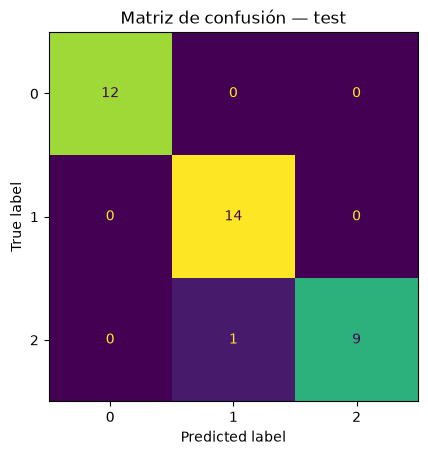

In [4]:
y_pred = model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
test_f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Accuracy test : {test_accuracy:.4f}")
print(f"F1 macro test : {test_f1_macro:.4f}")
print(f"Accuracy CV   : {training_metadata['cv_score']:.4f}\n")
print(classification_report(y_test, y_pred, digits=3))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, colorbar=False)
plt.title("Matriz de confusión — test")
plt.show()

**Análisis:**

> - **Coherencia con CV:** sí. Accuracy en test 0.972 (35 de 36) frente a 0.979 en CV; la diferencia es menor que la desviación entre folds (0.028). F1 macro 0.971.
> - **Clases confundidas:** el único error es un vino de la **clase 2 predicho como clase 1** (recall de la clase 2 = 0.90; precision de la clase 1 = 0.933). La clase 0 se clasifica perfectamente, lo que coincide con el EDA: `proline` la separa con claridad.
> - **Sobreajuste:** no hay evidencia relevante. El desempeño en test es casi igual al de CV. Con solo 36 vinos de test, cada error cambia el accuracy en ≈2.8 puntos, así que la estimación tiene incertidumbre.

## 3. Función de inferencia

In [5]:
feature_columns = contract["features"]

def predict(records: pd.DataFrame) -> pd.DataFrame:
    """Valida el esquema y devuelve las predicciones del pipeline."""
    missing = sorted(set(feature_columns) - set(records.columns))
    if missing:
        raise ValueError(f"Faltan variables requeridas: {missing}")
    X = records[feature_columns]                      # orden del contrato; ignora columnas extra
    probabilities = model.predict_proba(X)
    result = pd.DataFrame({"prediction": model.predict(X)}, index=records.index)
    for i, cls in enumerate(model.classes_):
        result[f"prob_class_{cls}"] = probabilities[:, i]
    return result

# Prueba rápida de la validación del esquema
try:
    predict(X_test.drop(columns=feature_columns[0]).iloc[:1])
except ValueError as e:
    print("Validación correcta ->", e)

Validación correcta -> Faltan variables requeridas: ['alcohol']


## 4. Predicción por lotes

In [6]:
# Simulación de datos nuevos. En producción no provendrían del test set.
new_records = X_test.iloc[:5].copy()

batch_predictions = predict(new_records)
batch_predictions.to_csv(REPORTS_DIR / "batch_predictions.csv", index=False)
batch_predictions.round(3)

,prediction,prob_class_0,prob_class_1,prob_class_2
0,0,1.000,0.000,0.000
1,1,0.007,0.540,0.453
2,0,0.992,0.008,0.000
3,1,0.290,0.707,0.003
4,1,0.033,0.962,0.005


## 5. Reporte final

In [7]:
test_metrics = {
    "model": training_metadata["champion"],
    "accuracy": float(test_accuracy),
    "f1_macro": float(test_f1_macro),
}
(REPORTS_DIR / "test_metrics.json").write_text(json.dumps(test_metrics, indent=2), encoding="utf-8")
test_metrics

{'model': 'logistic_regression',
 'accuracy': 0.9722222222222222,
 'f1_macro': 0.9709618874773139}

In [8]:
assert (REPORTS_DIR / "test_metrics.json").exists()
assert (REPORTS_DIR / "batch_predictions.csv").exists()
print("Challenge 3 completado.")

Challenge 3 completado.


## Resumen ejecutivo

| Elemento | Resultado |
|---|---|
| Modelo campeón | Regresión logística (`C=1`) con imputación por mediana + `StandardScaler` |
| Accuracy CV | 0.979 ± 0.028 (5 folds estratificados) |
| Accuracy test | 0.972 (35/36) |
| F1 macro test | 0.971 |
| Clases más confundidas | Clase 2 → clase 1 (1 vino) |
| Principal limitación | Dataset pequeño (178 vinos; 36 en test): métricas con alta varianza. El modelo no se ha probado con vinos de otras bodegas ni regiones. |

## Checklist

- [x] Evalué únicamente el modelo campeón.
- [x] No reajusté hiperparámetros después de observar test.
- [x] Implementé validación básica del esquema de entrada.
- [x] Generé predicciones por lotes.
- [x] Guardé las métricas finales.